# Case Study: Dự đoán số lượng lỗi phần mềm bằng Deep Learning



## 1. Import thư viện


In [1]:
from pathlib import Path
import re
import random
import warnings
import platform
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error
from sklearn.neighbors import NearestNeighbors
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR

from scipy.stats import kendalltau

import tensorflow as tf
from tensorflow.keras import Input, Model
from tensorflow.keras.layers import Dense, Dropout, Flatten, Concatenate, Conv1D, MaxPooling1D
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

warnings.filterwarnings("ignore")

RANDOM_STATE = 10
np.random.seed(RANDOM_STATE)
random.seed(RANDOM_STATE)
tf.random.set_seed(RANDOM_STATE)



## 2. Khai báo dataset


In [2]:
BASE_PATH = Path(r"PROMISE-backup\bug-data")

PROJECTS = ["ant", "camel", "jedit"]

PAPER_VERSION_FILTER = {
    "ant": {"1.3", "1.4", "1.5", "1.6", "1.7"},
    "camel": {"1.0", "1.2", "1.4", "1.6"},
    "jedit": {"3.2", "4.0", "4.1", "4.2", "4.3"},
}

USE_PAPER_VERSION_FILTER = True

FEATURES = [
    "wmc", "dit", "noc", "cbo",
    "rfc", "lcom", "ca", "ce",
    "npm", "lcom3", "loc", "dam",
    "moa", "mfa", "cam", "ic",
    "cbm", "amc", "max_cc", "avg_cc"
]
TARGET = "bug"

OUTPUT_DIR = Path("outputs_promise_fault_prediction_9_5")
OUTPUT_DIR.mkdir(exist_ok=True)


## 3. Đọc và gộp dữ liệu từ PROMISE bug-data


In [3]:
def get_version(file_path):
    return file_path.stem.split("-", 1)[1]


all_frames = []
file_summary = []

version_filter = PAPER_VERSION_FILTER if USE_PAPER_VERSION_FILTER else None

for project in PROJECTS:
    folder = BASE_PATH / project

    for file_path in sorted(folder.glob("*.csv")):
        version = get_version(file_path)

        if version_filter is not None and version not in version_filter.get(project, set()):
            continue

        df = pd.read_csv(file_path)
        df.columns = df.columns.str.strip().str.lower()

        df["project"] = project
        df["version"] = version
        df["source_file"] = file_path.name

        all_frames.append(df)

        file_summary.append({
            "project": project,
            "version": version,
            "file": file_path.name,
            "rows": len(df),
            "columns": df.shape[1]
        })

raw_df = pd.concat(all_frames, ignore_index=True)
file_summary = pd.DataFrame(file_summary)

print("Số file đã đọc:", len(file_summary))
display(file_summary)

print("Kích thước dữ liệu sau khi gộp:", raw_df.shape)
display(raw_df.head())

Số file đã đọc: 14


,project,version,file,rows,columns
0,ant,1.3,ant-1.3.csv,125,25
1,ant,1.4,ant-1.4.csv,178,25
2,ant,1.5,ant-1.5.csv,293,25
3,ant,1.6,ant-1.6.csv,351,25
4,ant,1.7,ant-1.7.csv,745,25
5,camel,1.0,camel-1.0.csv,339,25
6,camel,1.2,camel-1.2.csv,608,25
7,camel,1.4,camel-1.4.csv,872,25
8,camel,1.6,camel-1.6.csv,965,25
9,jedit,3.2,jedit-3.2.csv,272,25


Kích thước dữ liệu sau khi gộp: (6225, 25)


,name,wmc,dit,noc,cbo,rfc,lcom,ca,ce,npm,...,cam,ic,cbm,amc,max_cc,avg_cc,bug,project,version,source_file
0,org.apache.tools.ant.taskdefs.ExecuteOn,11,4,2,14,42,29,2,12,5,...,0.232323,3,4,34.545455,3,1.2727,0,ant,1.3,ant-1.3.csv
1,org.apache.tools.ant.DefaultLogger,14,1,1,8,32,49,4,4,12,...,0.307692,0,0,16.857143,6,1.6429,2,ant,1.3,ant-1.3.csv
2,org.apache.tools.ant.taskdefs.TaskOutputStream,3,2,0,1,9,0,0,1,1,...,0.666667,1,1,17.333333,1,0.6667,0,ant,1.3,ant-1.3.csv
3,org.apache.tools.ant.taskdefs.Cvs,12,3,0,12,37,32,0,12,12,...,0.458333,0,0,24.083333,3,1.4167,0,ant,1.3,ant-1.3.csv
4,org.apache.tools.ant.taskdefs.Copyfile,6,3,0,4,21,1,0,4,6,...,0.416667,2,2,21.000000,1,0.8333,0,ant,1.3,ant-1.3.csv


## 4. Làm sạch dữ liệu


In [4]:
required_columns = FEATURES + [TARGET]
missing_columns = [col for col in required_columns if col not in raw_df.columns]
if missing_columns:
    raise ValueError("Thiếu các cột bắt buộc: " + str(missing_columns))


def basic_cleaning(df: pd.DataFrame) -> pd.DataFrame:
    cleaned = df.copy()

    id_cols = [col for col in ["project", "version", "source_file", "name"] if col in cleaned.columns]
    cleaned = cleaned[id_cols + FEATURES + [TARGET]].copy()

    for col in FEATURES + [TARGET]:
        cleaned[col] = pd.to_numeric(cleaned[col], errors="coerce")

    n_before = len(cleaned)
    n_missing = int(cleaned[FEATURES + [TARGET]].isna().any(axis=1).sum())

    cleaned = cleaned.dropna(subset=FEATURES + [TARGET]).copy()

    n_duplicate_model_cols = int(cleaned.duplicated(subset=FEATURES + [TARGET]).sum())
    cleaned = cleaned.drop_duplicates(subset=FEATURES + [TARGET]).reset_index(drop=True)

    print("Kích thước trước xử lý:", df.shape)
    print("Số dòng thiếu dữ liệu:", n_missing)
    print("Số dòng trùng theo FEATURES + bug:", n_duplicate_model_cols)
    print("Kích thước sau xử lý:", cleaned.shape)
    print("Số dòng bị loại:", n_before - len(cleaned))

    return cleaned


clean_df = basic_cleaning(raw_df)
display(clean_df.head())

Kích thước trước xử lý: (6225, 25)
Số dòng thiếu dữ liệu: 0
Số dòng trùng theo FEATURES + bug: 1173
Kích thước sau xử lý: (5052, 25)
Số dòng bị loại: 1173


,project,version,source_file,name,wmc,dit,noc,cbo,rfc,lcom,...,dam,moa,mfa,cam,ic,cbm,amc,max_cc,avg_cc,bug
0,ant,1.3,ant-1.3.csv,org.apache.tools.ant.taskdefs.ExecuteOn,11,4,2,14,42,29,...,1.0,1,0.885057,0.232323,3,4,34.545455,3,1.2727,0
1,ant,1.3,ant-1.3.csv,org.apache.tools.ant.DefaultLogger,14,1,1,8,32,49,...,1.0,0,0.000000,0.307692,0,0,16.857143,6,1.6429,2
2,ant,1.3,ant-1.3.csv,org.apache.tools.ant.taskdefs.TaskOutputStream,3,2,0,1,9,0,...,1.0,1,0.714286,0.666667,1,1,17.333333,1,0.6667,0
3,ant,1.3,ant-1.3.csv,org.apache.tools.ant.taskdefs.Cvs,12,3,0,12,37,32,...,1.0,1,0.770833,0.458333,0,0,24.083333,3,1.4167,0
4,ant,1.3,ant-1.3.csv,org.apache.tools.ant.taskdefs.Copyfile,6,3,0,4,21,1,...,1.0,0,0.880952,0.416667,2,2,21.000000,1,0.8333,0


## 5. Thống kê dataset và phân bố biến mục tiêu

In [5]:
print("Thống kê số dòng theo project/version:")
dataset_table = clean_df.groupby(["project", "version"]).agg(
    rows=(TARGET, "size"),
    faulty_classes=(TARGET, lambda s: int((s > 0).sum())), 
    non_faulty_classes=(TARGET, lambda s: int((s == 0).sum())),
    max_bug=(TARGET, "max"),
    mean_bug=(TARGET, "mean"),
).reset_index()
dataset_table["faulty_rate_%"] = (dataset_table["faulty_classes"] / dataset_table["rows"] * 100).round(2)
display(dataset_table)

print("Thống kê biến mục tiêu bug:")
display(clean_df[TARGET].describe())

faulty_count = int((clean_df[TARGET] > 0).sum())
non_faulty_count = int((clean_df[TARGET] == 0).sum())
print("Số class không lỗi bug = 0:", non_faulty_count)
print("Số class có lỗi bug > 0:", faulty_count)
print("Tỷ lệ class có lỗi:", round(faulty_count / len(clean_df) * 100, 2), "%")

bug_count_table = clean_df[TARGET].value_counts().sort_index().rename_axis("bug").reset_index(name="count")
bug_count_table["percent"] = (bug_count_table["count"] / len(clean_df) * 100).round(2)
print("Phân bố các giá trị bug:")
display(bug_count_table.head(30))

dataset_table.to_csv(OUTPUT_DIR / "table_dataset_summary.csv", index=False)
bug_count_table.to_csv(OUTPUT_DIR / "table_bug_distribution.csv", index=False)

Thống kê số dòng theo project/version:


,project,version,rows,faulty_classes,non_faulty_classes,max_bug,mean_bug,faulty_rate_%
0,ant,1.3,125,20,105,3,0.264000,16.00
1,ant,1.4,145,39,106,3,0.317241,26.90
2,ant,1.5,266,32,234,2,0.131579,12.03
3,ant,1.6,284,92,192,10,0.647887,32.39
4,ant,1.7,677,166,511,10,0.499261,24.52
5,camel,1.0,322,13,309,2,0.043478,4.04
6,camel,1.2,503,211,292,28,1.021869,41.95
7,camel,1.4,664,136,528,17,0.490964,20.48
8,camel,1.6,624,181,443,28,0.790064,29.01
9,jedit,3.2,268,90,178,45,1.425373,33.58


Thống kê biến mục tiêu bug:


count    5052.000000
mean        0.578583
std         1.800801
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        45.000000
Name: bug, dtype: float64

Số class không lỗi bug = 0: 3862
Số class có lỗi bug > 0: 1190
Tỷ lệ class có lỗi: 23.56 %
Phân bố các giá trị bug:


,bug,count,percent
0,0,3862,76.44
1,1,616,12.19
2,2,236,4.67
3,3,133,2.63
4,4,74,1.46
5,5,35,0.69
6,6,24,0.48
7,7,17,0.34
8,8,15,0.30
9,9,11,0.22


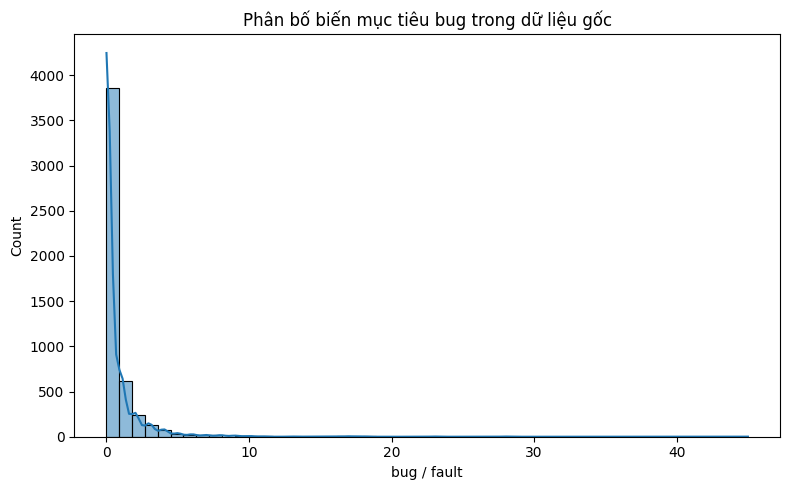

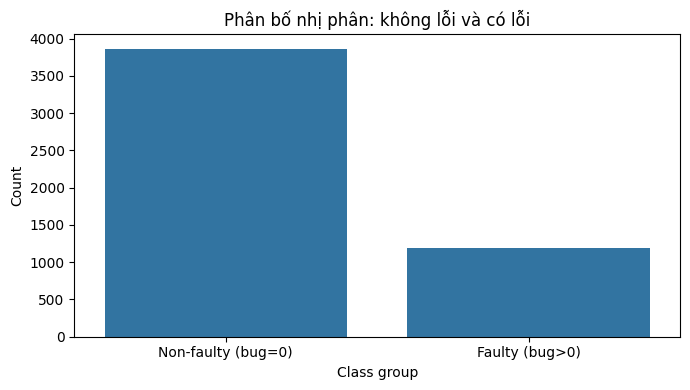

In [6]:
plt.figure(figsize=(8, 5))
sns.histplot(clean_df[TARGET], bins=50, kde=True)
plt.title("Phân bố biến mục tiêu bug trong dữ liệu gốc")
plt.xlabel("bug / fault")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "phân bố biến mục tiêu bug trong dữ liệu gốc.png", dpi=200)
plt.show()

plt.figure(figsize=(7, 4))
sns.countplot(x=(clean_df[TARGET] > 0).map({False: "Non-faulty (bug=0)", True: "Faulty (bug>0)"}))
plt.title("Phân bố nhị phân: không lỗi và có lỗi")
plt.xlabel("Class group")
plt.ylabel("Count")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Phân bố nhị phân: không lỗi và có lỗi.png", dpi=200)
plt.show()

## 6. Ma trận tương quan


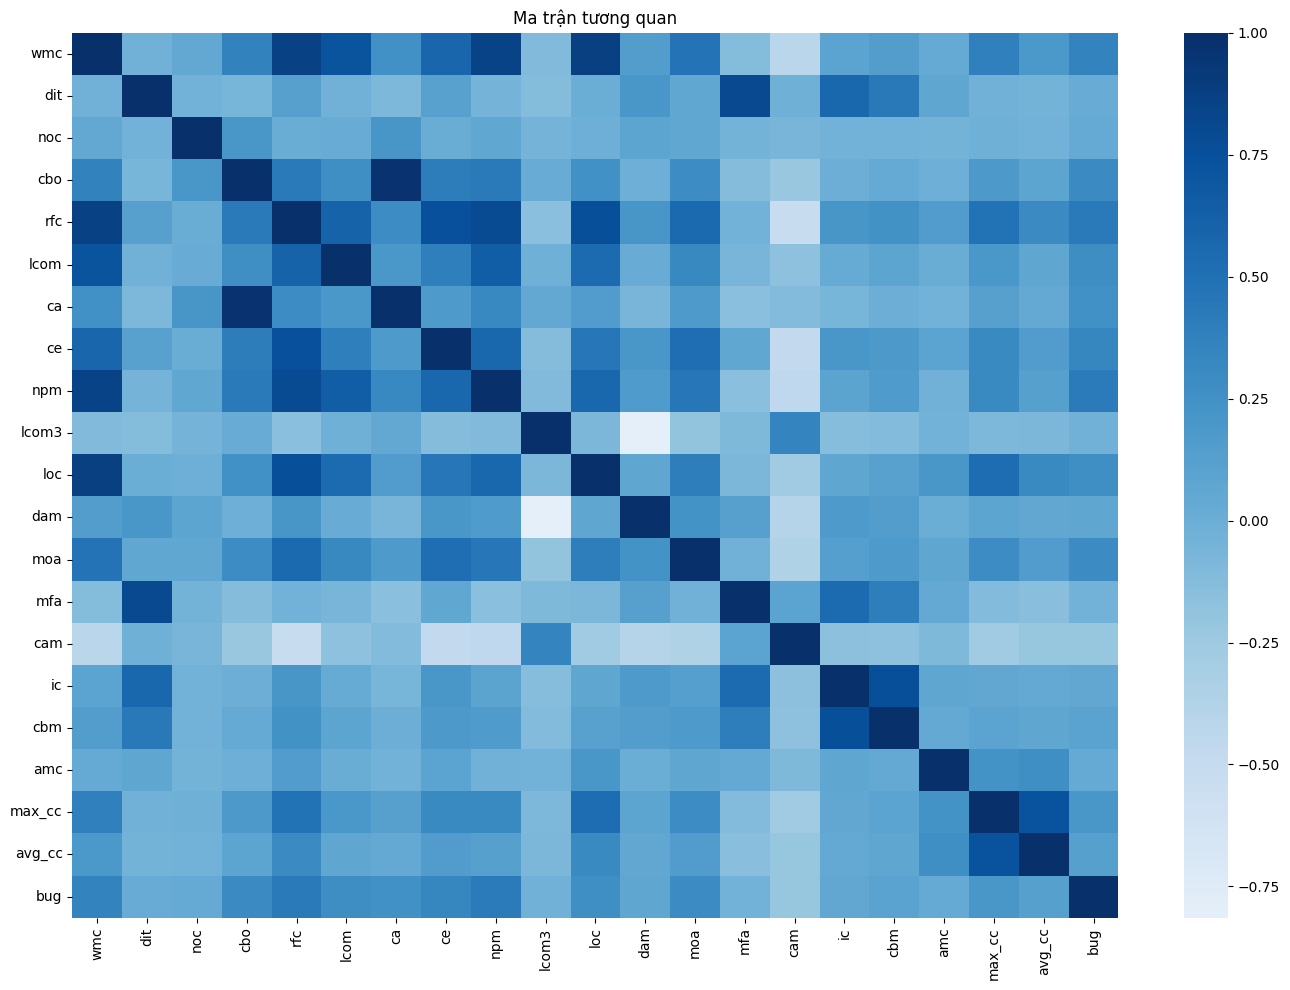

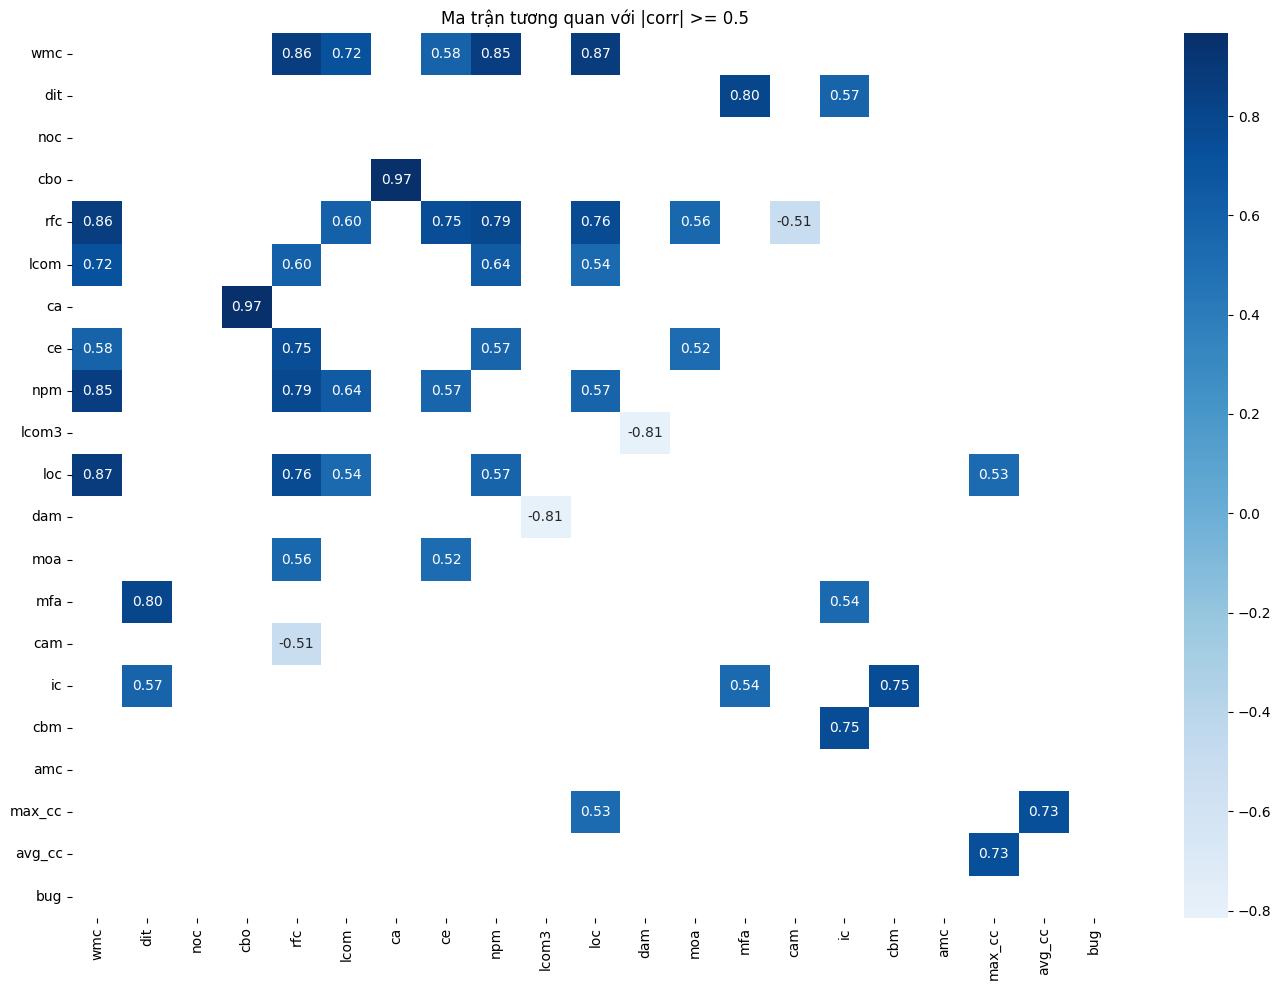

Top feature tương quan với bug theo trị tuyệt đối:


,corr_with_bug
rfc,0.430762
npm,0.424120
wmc,0.355232
ce,0.338207
cbo,0.302540
moa,0.297530
lcom,0.271296
loc,0.265691
ca,0.248899
cam,-0.214071


In [7]:
corr = clean_df[FEATURES + [TARGET]].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr, cmap="Blues", center=0, annot=False)
plt.title("Ma trận tương quan")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "Ma trận tương quan.png", dpi=200)
plt.show()

threshold = 0.5
strong_corr = corr.where((corr.abs() >= threshold) & (corr.abs() < 1.0))

plt.figure(figsize=(14, 10))
sns.heatmap(strong_corr, cmap="Blues", center=0, annot=True, fmt=".2f")
plt.title(f"Ma trận tương quan với |corr| >= {threshold}")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_strong_correlation_matrix.png", dpi=200)
plt.show()

bug_corr = corr[TARGET].drop(TARGET).sort_values(key=lambda s: s.abs(), ascending=False)
bug_corr_df = bug_corr.to_frame("corr_with_bug")
print("Top feature tương quan với bug theo trị tuyệt đối:")
display(bug_corr_df)

bug_corr_df.to_csv(OUTPUT_DIR / "table_correlation_with_bug.csv")

## 9. SMOTEND-style oversampling

Bài báo dùng SMOTEND để xử lý mất cân bằng dữ liệu. Trong notebook này, ta cài trực tiếp phiên bản **SMOTEND-style** theo ý tưởng:

- Majority: class không lỗi, `bug = 0`
- Minority: class có lỗi, `bug > 0`
- Sinh thêm dữ liệu synthetic từ các mẫu faulty gần nhau
- Target synthetic là trung bình có trọng số theo khoảng cách giữa 2 mẫu
Tham số mặc định:

- `k = 5`
- `m = 6`, nghĩa là sinh đủ để cân bằng với majority nếu minority đang ít hơn
- `r = 2`, Minkowski distance tương đương Euclidean distance

In [8]:
def minkowski_distance(a: np.ndarray, b: np.ndarray, r: float = 2.0) -> float:
    return float(np.sum(np.abs(a - b) ** r) ** (1.0 / r))
def smotend_oversample(
    X: pd.DataFrame,
    y_bug: pd.Series,
    random_state: int = 10,
    k_neighbors: int = 5,
    m: int = 6,
    r: float = 2.0,
    n_parts: int = 6,
) -> tuple[pd.DataFrame, pd.Series, dict]:
    
    rng = np.random.default_rng(random_state)

    X_values = X.astype(float).to_numpy()
    y_values = y_bug.astype(float).to_numpy()

    minority_mask = y_values > 0
    majority_mask = y_values == 0

    X_min = X_values[minority_mask]
    y_min = y_values[minority_mask]
    n_min = len(X_min)
    n_maj = int(majority_mask.sum())

    summary = {
        "majority_non_faulty": n_maj,
        "minority_faulty": n_min,
        "k_neighbors": k_neighbors,
        "m": m,
        "r": r,
        "n_parts": n_parts,
        "synthetic_generated": 0,
        "note": "",
    }

    if n_min == 0:
        summary["note"] = "Không có faulty class, không thể SMOTEND."
        return X.copy(), y_bug.copy(), summary

    if n_min >= n_maj:
        summary["note"] = (
            "Faulty không ít hơn non-faulty trong subset này, "
            "SMOTEND theo định nghĩa paper không sinh thêm mẫu."
        )
        return X.copy(), y_bug.copy(), summary

    num_synthetic = int(round((n_maj - n_min) * m / n_parts))
    summary["synthetic_generated"] = num_synthetic

    if num_synthetic <= 0:
        summary["note"] = "num_synthetic <= 0, không sinh thêm mẫu."
        return X.copy(), y_bug.copy(), summary

    effective_k = min(k_neighbors + 1, n_min)
    nn = NearestNeighbors(n_neighbors=effective_k, metric="minkowski", p=r)
    nn.fit(X_min)
    neighbor_indices = nn.kneighbors(X_min, return_distance=False)

    if effective_k > 1:
        neighbor_indices = neighbor_indices[:, 1:]
    else:
        neighbor_indices = neighbor_indices[:, :1]

    synthetic_X = []
    synthetic_y = []

    index = 0
    while len(synthetic_X) < num_synthetic:
        v1 = X_min[index]
        y1 = y_min[index]

        neighbors = neighbor_indices[index]
        if len(neighbors) == 0:
            chosen_neighbor_idx = index
        else:
            chosen_neighbor_idx = int(rng.choice(neighbors))

        v2 = X_min[chosen_neighbor_idx]
        y2 = y_min[chosen_neighbor_idx]

        lam = float(rng.random())
        new_x = v1 + lam * (v2 - v1)

        d1 = minkowski_distance(new_x, v1, r=r)
        d2 = minkowski_distance(new_x, v2, r=r)
        denom = d1 + d2

        if denom == 0:
            new_y = (y1 + y2) / 2.0
        else:
            new_y = (d1 * y2 + d2 * y1) / denom

        new_y = max(0.0, float(new_y))

        synthetic_X.append(new_x)
        synthetic_y.append(new_y)

        index = (index + 1) % n_min

    X_syn = pd.DataFrame(synthetic_X, columns=X.columns)
    y_syn = pd.Series(synthetic_y, name=y_bug.name)

    X_balanced = pd.concat([X.reset_index(drop=True), X_syn], ignore_index=True)
    y_balanced = pd.concat([y_bug.reset_index(drop=True), y_syn], ignore_index=True)

    summary["note"] = "Đã sinh synthetic faulty samples bằng SMOTEND-style."
    return X_balanced, y_balanced, summary

## 10. Chuẩn bị dữ liệu cho 2 thí nghiệm

- **Experiment 1:** Không dùng SMOTEND.
- **Experiment 2:** Có dùng SMOTEND-style.

In [9]:
def prepare_experiment_data(clean_df: pd.DataFrame, use_smotend: bool):
    X_raw = clean_df[FEATURES].copy()
    y_bug_raw = clean_df[TARGET].astype(float).copy()

    smotend_summary = None

    if use_smotend:
        X_work, y_bug_work, smotend_summary = smotend_oversample(
            X_raw,
            y_bug_raw,
            random_state=RANDOM_STATE,
            k_neighbors=5,
            m=6,
            r=2.0,
            n_parts=6,
        )
    else:
        X_work = X_raw.copy().reset_index(drop=True)
        y_bug_work = y_bug_raw.copy().reset_index(drop=True)
        smotend_summary = {
            "majority_non_faulty": int((y_bug_work == 0).sum()),
            "minority_faulty": int((y_bug_work > 0).sum()),
            "synthetic_generated": 0,
            "note": "Experiment không dùng SMOTEND."
        }

    y_log = np.log1p(y_bug_work.astype(float).to_numpy())

    stratify_labels = (y_bug_work > 0).astype(int)
    can_stratify = stratify_labels.nunique() == 2 and stratify_labels.value_counts().min() >= 2

    X_train_raw, X_test_raw, y_train, y_test, y_bug_train, y_bug_test = train_test_split(
        X_work,
        y_log,
        y_bug_work.to_numpy(),
        test_size=0.30,
        random_state=RANDOM_STATE,
        shuffle=True,
        stratify=stratify_labels if can_stratify else None,
    )

    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train_raw)
    X_test = scaler.transform(X_test_raw)

    data_info = {
        "X_work": X_work,
        "y_bug_work": y_bug_work,
        "y_log": y_log,
        "scaler": scaler,
        "smotend_summary": smotend_summary,
        "train_size": len(X_train),
        "test_size": len(X_test),
    }

    return X_train, X_test, y_train, y_test, y_bug_train, y_bug_test, data_info


X_train_no, X_test_no, y_train_no, y_test_no, y_bug_train_no, y_bug_test_no, info_no = prepare_experiment_data(clean_df, use_smotend=False)
X_train_sm, X_test_sm, y_train_sm, y_test_sm, y_bug_train_sm, y_bug_test_sm, info_sm = prepare_experiment_data(clean_df, use_smotend=True)

print("Experiment 1 - without SMOTEND")
print("Train:", X_train_no.shape, "Test:", X_test_no.shape)
print(info_no["smotend_summary"])

print("\nExperiment 2 - with SMOTEND-style")
print("Train:", X_train_sm.shape, "Test:", X_test_sm.shape)
print(info_sm["smotend_summary"])

Experiment 1 - without SMOTEND
Train: (3536, 20) Test: (1516, 20)
{'majority_non_faulty': 3862, 'minority_faulty': 1190, 'synthetic_generated': 0, 'note': 'Experiment không dùng SMOTEND.'}

Experiment 2 - with SMOTEND-style
Train: (5406, 20) Test: (2318, 20)
{'majority_non_faulty': 3862, 'minority_faulty': 1190, 'k_neighbors': 5, 'm': 6, 'r': 2.0, 'n_parts': 6, 'synthetic_generated': 2672, 'note': 'Đã sinh synthetic faulty samples bằng SMOTEND-style.'}


## 11. Phân bố sau SMOTEND và sau log transformation



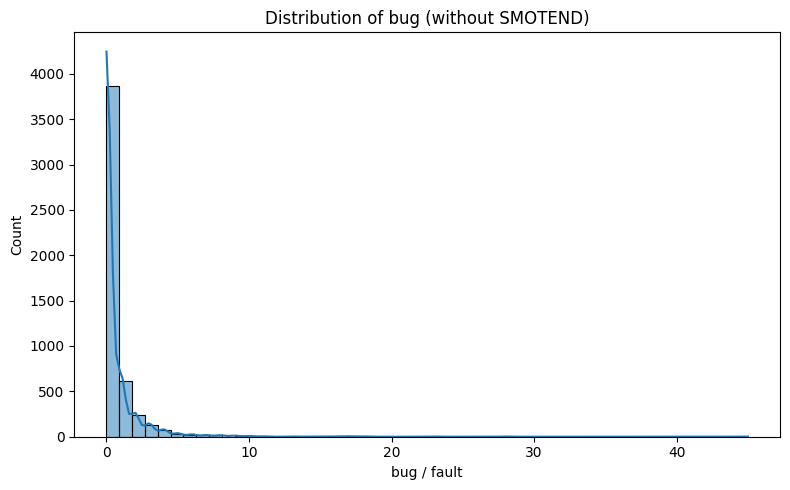

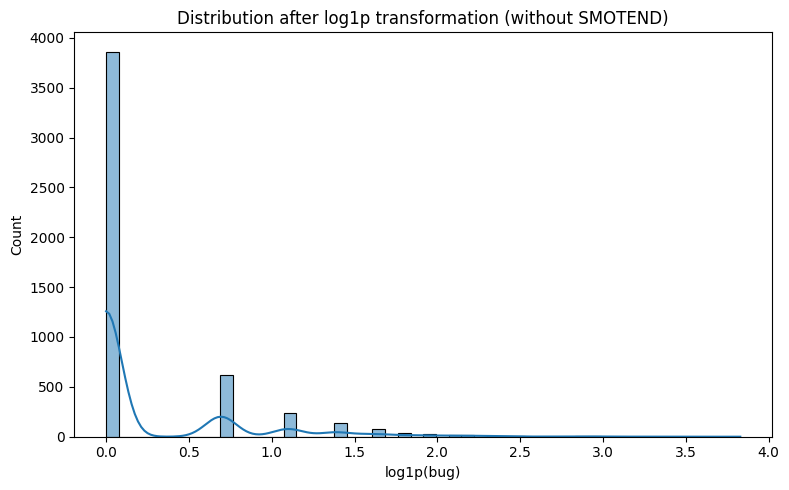

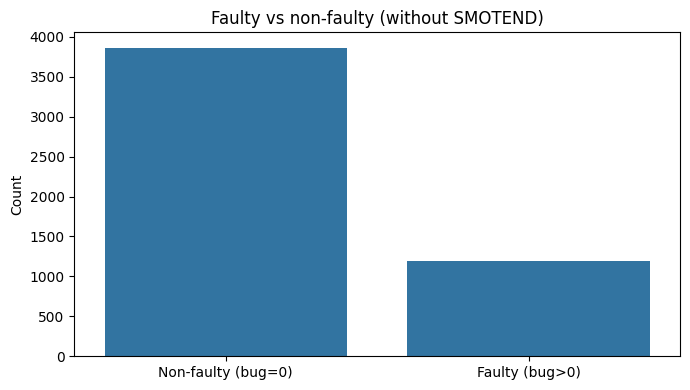

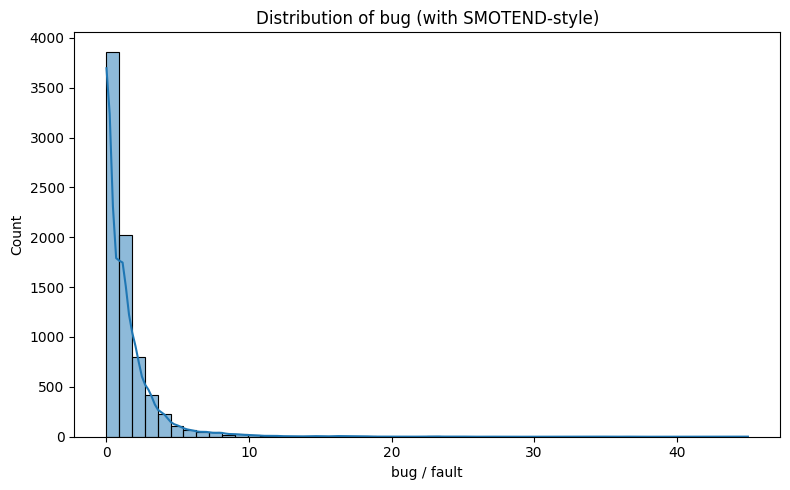

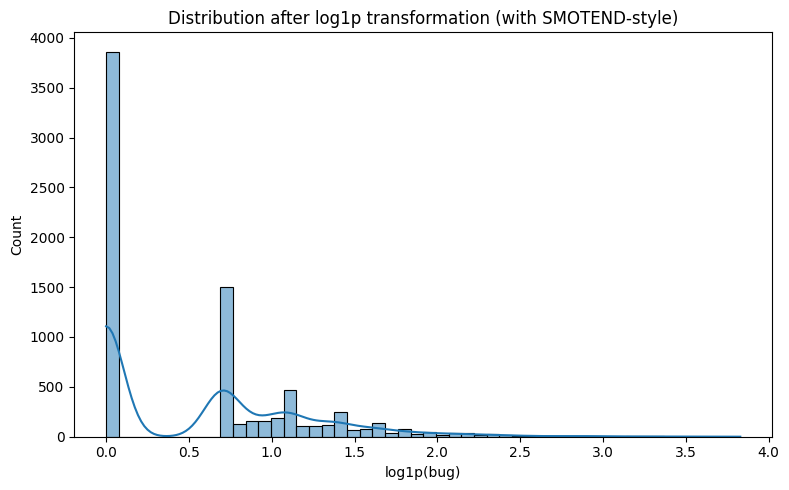

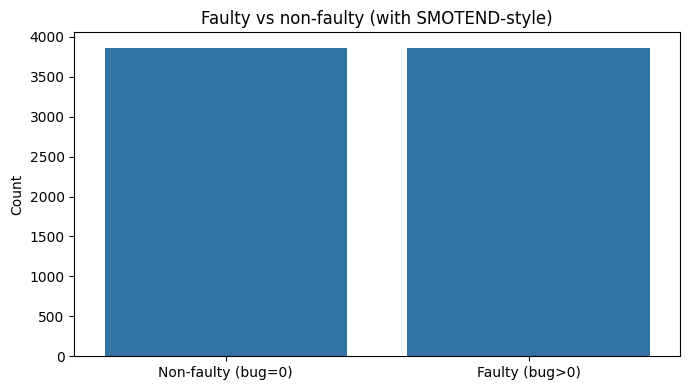

In [10]:
def plot_target_distribution(y_bug, y_log, title_suffix, filename_prefix):
    fig_df = pd.DataFrame({
        "bug": np.asarray(y_bug),
        "log1p_bug": np.asarray(y_log),
        "fault_group": np.where(np.asarray(y_bug) > 0, "Faulty (bug>0)", "Non-faulty (bug=0)")
    })

    plt.figure(figsize=(8, 5))
    sns.histplot(fig_df["bug"], bins=50, kde=True)
    plt.title(f"Distribution of bug {title_suffix}")
    plt.xlabel("bug / fault")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{filename_prefix}_bug_distribution.png", dpi=200)
    plt.show()

    plt.figure(figsize=(8, 5))
    sns.histplot(fig_df["log1p_bug"], bins=50, kde=True)
    plt.title(f"Distribution after log1p transformation {title_suffix}")
    plt.xlabel("log1p(bug)")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{filename_prefix}_log_distribution.png", dpi=200)
    plt.show()

    plt.figure(figsize=(7, 4))
    sns.countplot(data=fig_df, x="fault_group")
    plt.title(f"Faulty vs non-faulty {title_suffix}")
    plt.xlabel("")
    plt.ylabel("Count")
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / f"{filename_prefix}_faulty_non_faulty.png", dpi=200)
    plt.show()


plot_target_distribution(info_no["y_bug_work"], info_no["y_log"], "(without SMOTEND)", "exp1_without_smotend")
plot_target_distribution(info_sm["y_bug_work"], info_sm["y_log"], "(with SMOTEND-style)", "exp2_with_smotend")

## 12. Chia 20 feature thành 5 nhóm theo kiến trúc bài báo

Bài báo chia 20 software metrics thành 5 nhóm, mỗi nhóm 4 feature:

1. `WMC, DIT, NOC, CBO`
2. `RFC, LCOM, CA, CE`
3. `NPM, LCOM3, LOC, DAM`
4. `MOA, MFA, CAM, IC`
5. `CBM, AMC, MAX_CC, AVG_CC`

In [11]:
FEATURE_GROUPS = [
    ["wmc", "dit", "noc", "cbo"],
    ["rfc", "lcom", "ca", "ce"],
    ["npm", "lcom3", "loc", "dam"],
    ["moa", "mfa", "cam", "ic"],
    ["cbm", "amc", "max_cc", "avg_cc"],
]

feature_to_index = {feature: idx for idx, feature in enumerate(FEATURES)}
GROUP_INDICES = [[feature_to_index[f] for f in group] for group in FEATURE_GROUPS]

for i, group in enumerate(FEATURE_GROUPS, start=1):
    print(f"Group {i}:", group)


def split_groups_for_mlp(X_array: np.ndarray):
    return [X_array[:, idxs] for idxs in GROUP_INDICES]


def split_groups_for_cnn(X_array: np.ndarray):
    return [X_array[:, idxs].reshape(-1, 4, 1) for idxs in GROUP_INDICES]

Group 1: ['wmc', 'dit', 'noc', 'cbo']
Group 2: ['rfc', 'lcom', 'ca', 'ce']
Group 3: ['npm', 'lcom3', 'loc', 'dam']
Group 4: ['moa', 'mfa', 'cam', 'ic']
Group 5: ['cbm', 'amc', 'max_cc', 'avg_cc']


In [12]:
def build_cnn_model(learning_rate=0.001):
    inputs = [Input(shape=(4, 1), name=f"input_group_cnn_{i+1}") for i in range(5)]

    flattened_outputs = []
    for inp in inputs:
        x = Conv1D(
            filters=32,
            kernel_size=2,
            activation="relu",
            kernel_initializer="glorot_uniform",
            padding="same",
        )(inp)
        x = MaxPooling1D(pool_size=2)(x)
        x = Dropout(0.2, seed=RANDOM_STATE)(x)
        x = Flatten()(x)
        flattened_outputs.append(x)

    merged = Concatenate()(flattened_outputs)
    x = Dense(64, activation="relu", kernel_initializer="glorot_uniform")(merged)
    x = Dropout(0.2, seed=RANDOM_STATE)(x)
    output = Dense(1, activation="linear", name="output_cnn")(x)

    model = Model(inputs=inputs, outputs=output, name="Parallel_CNN")
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model


def build_mlp_model(learning_rate=0.001):
    inputs = [Input(shape=(4,), name=f"input_group_mlp_{i+1}") for i in range(5)]

    dense_outputs = []
    for inp in inputs:
        x = Dense(16, activation="relu", kernel_initializer="glorot_uniform")(inp)
        x = Dropout(0.2, seed=RANDOM_STATE)(x)
        dense_outputs.append(x)

    merged = Concatenate()(dense_outputs)
    x = Dense(64, activation="relu", kernel_initializer="glorot_uniform")(merged)
    x = Dropout(0.2, seed=RANDOM_STATE)(x)
    output = Dense(1, activation="linear", name="output_mlp")(x)

    model = Model(inputs=inputs, outputs=output, name="Parallel_MLP")
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="mse")
    return model

## 133. Hàm đánh giá



In [13]:
def safe_kendall(y_true, y_pred):
    result = kendalltau(np.ravel(y_true), np.ravel(y_pred))
    if result.correlation is None or np.isnan(result.correlation):
        return 0.0
    return float(result.correlation)


def evaluate_regression(y_true_log, y_pred_log):
    y_pred_log = np.ravel(y_pred_log)
    y_true_log = np.ravel(y_true_log)

    y_true_bug = np.expm1(y_true_log)
    y_pred_bug = np.maximum(0, np.expm1(y_pred_log))

    return {
        "Kendall": round(safe_kendall(y_true_log, y_pred_log), 4),
        "MSE": round(mean_squared_error(y_true_log, y_pred_log), 4),
        "MSE_original_bug_scale": round(mean_squared_error(y_true_bug, y_pred_bug), 4),
    }


def train_deep_model(
    model_name: str,
    experiment_name: str,
    X_train: np.ndarray,
    X_test: np.ndarray,
    y_train: np.ndarray,
    y_test: np.ndarray,
    epochs: int = 100,
    batch_size: int = 16,
    learning_rate: float = 0.001,
):
    tf.keras.backend.clear_session()
    tf.random.set_seed(RANDOM_STATE)

    if model_name.upper() == "CNN":
        model = build_cnn_model(learning_rate=learning_rate)
        X_train_input = split_groups_for_cnn(X_train)
        X_test_input = split_groups_for_cnn(X_test)
    elif model_name.upper() == "MLP":
        model = build_mlp_model(learning_rate=learning_rate)
        X_train_input = split_groups_for_mlp(X_train)
        X_test_input = split_groups_for_mlp(X_test)
    else:
        raise ValueError("model_name phải là CNN hoặc MLP")

    callbacks = [
        EarlyStopping(
            monitor="val_loss",
            patience=15,
            restore_best_weights=True,
            verbose=0
        ),
        ReduceLROnPlateau(
            monitor="val_loss",
            factor=0.5,
            patience=7,
            min_lr=1e-5,
            verbose=0
        )
    ]

    print(f"\nTraining {model_name} - {experiment_name}")

    history = model.fit(
        X_train_input,
        y_train,
        validation_split=0.20,
        epochs=epochs,
        batch_size=batch_size,
        callbacks=callbacks,
        verbose=1,
    )

    pred_train = model.predict(X_train_input, verbose=0)
    pred_test = model.predict(X_test_input, verbose=0)

    rows = [
        {"Experiment": experiment_name, "Model": model_name, "Dataset": "Train", **evaluate_regression(y_train, pred_train)},
        {"Experiment": experiment_name, "Model": model_name, "Dataset": "Test", **evaluate_regression(y_test, pred_test)},
    ]

    return model, history, rows

## 144. Train CNN và MLP trước/sau SMOTEND



In [14]:
EPOCHS = 100
BATCH_SIZE = 16
LEARNING_RATE = 0.001

all_results = []
histories = {}
models = {}

experiments = [
    ("Experiment 1 - without SMOTEND", X_train_no, X_test_no, y_train_no, y_test_no),
    ("Experiment 2 - with SMOTEND", X_train_sm, X_test_sm, y_train_sm, y_test_sm),
]

for exp_name, Xtr, Xte, ytr, yte in experiments:
    for model_name in ["CNN", "MLP"]:
        model, history, rows = train_deep_model(
            model_name=model_name,
            experiment_name=exp_name,
            X_train=Xtr,
            X_test=Xte,
            y_train=ytr,
            y_test=yte,
            epochs=EPOCHS,
            batch_size=BATCH_SIZE,
            learning_rate=LEARNING_RATE,
        )
        key = f"{model_name}_{exp_name}"
        models[key] = model
        histories[key] = history
        all_results.extend(rows)

deep_results_df = pd.DataFrame(all_results)
display(deep_results_df)
deep_results_df.to_csv(OUTPUT_DIR / "table_deep_learning_results.csv", index=False)



Training CNN - Experiment 1 - without SMOTEND
Epoch 1/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.2957 - val_loss: 0.2069 - learning_rate: 0.0010
Epoch 2/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2572 - val_loss: 0.2187 - learning_rate: 0.0010
Epoch 3/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2527 - val_loss: 0.2024 - learning_rate: 0.0010
Epoch 4/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2342 - val_loss: 0.2097 - learning_rate: 0.0010
Epoch 5/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2374 - val_loss: 0.2068 - learning_rate: 0.0010
Epoch 6/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2325 - val_loss: 0.2064 - learning_rate: 0.0010
Epoch 7/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2353 - val_loss: 0.2129 - learning_rate: 0.0010
Epoch 8/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2364 - val_loss: 0.2076 - learning_rate: 0.0010
Epoch 9/100
177/177 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.2

,Experiment,Model,Dataset,Kendall,MSE,MSE_original_bug_scale
0,Experiment 1 - without SMOTEND,CNN,Train,0.2539,0.2116,2.4145
1,Experiment 1 - without SMOTEND,CNN,Test,0.2228,0.2168,3.2937
2,Experiment 1 - without SMOTEND,MLP,Train,0.2760,0.2082,2.3134
3,Experiment 1 - without SMOTEND,MLP,Test,0.2291,0.2239,3.4150
4,Experiment 2 - with SMOTEND,CNN,Train,0.5317,0.2001,2.7214
5,Experiment 2 - with SMOTEND,CNN,Test,0.4751,0.2441,3.2271
6,Experiment 2 - with SMOTEND,MLP,Train,0.5651,0.1823,2.1724
7,Experiment 2 - with SMOTEND,MLP,Test,0.4818,0.2386,3.4194


## 15. Biểu đồ Training Loss và Validation Loss



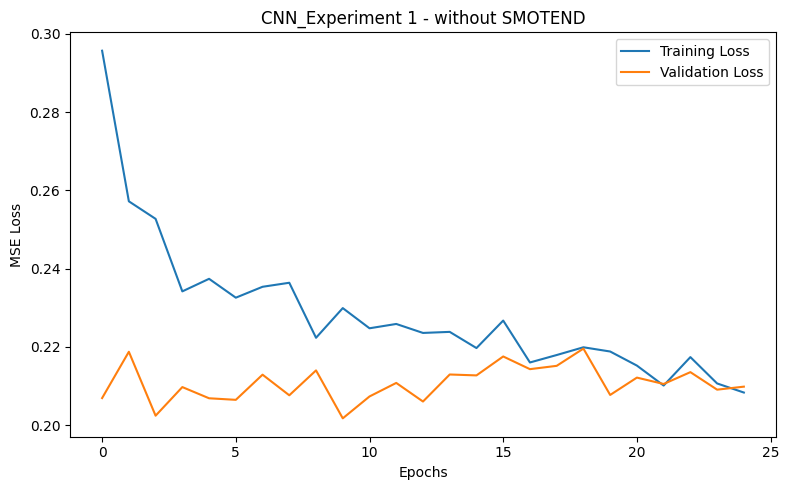

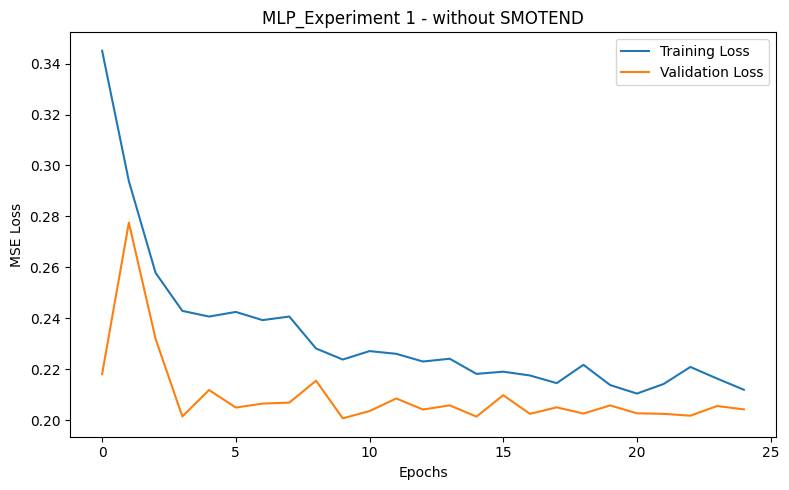

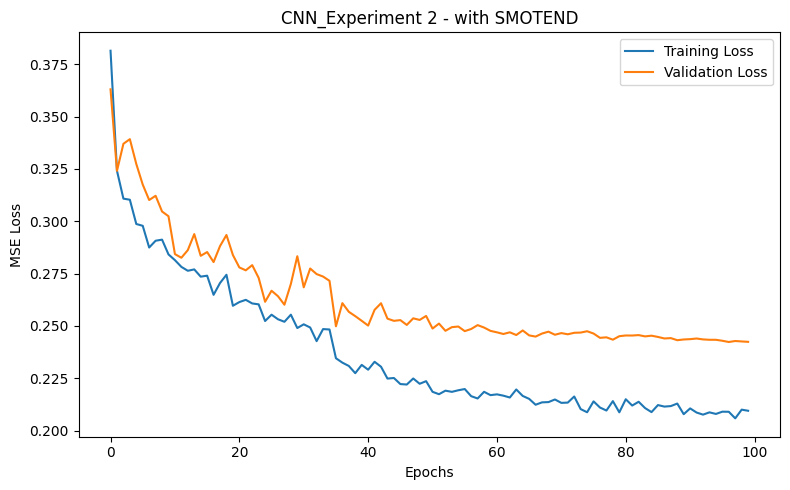

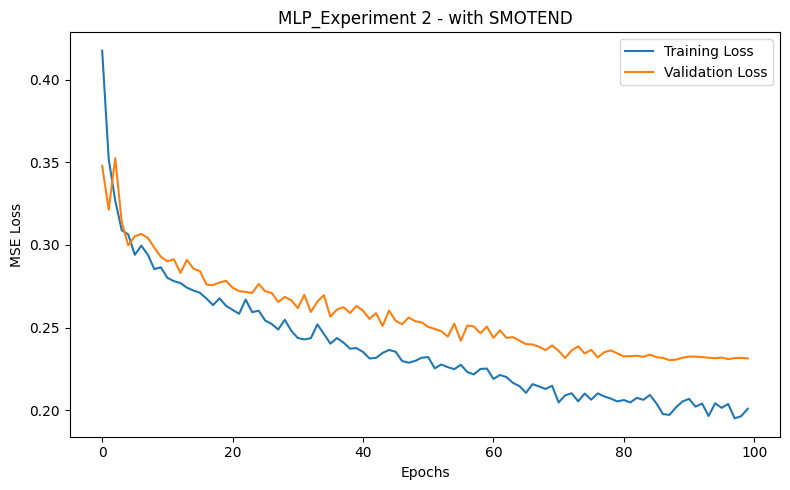

,Model_Experiment,epochs_ran,best_epoch_by_val_loss,final_train_loss,final_val_loss,final_val_train_gap,best_train_loss,best_val_loss,best_val_train_gap
0,CNN_Experiment 1 - without SMOTEND,25,10,0.2083,0.2098,0.0015,0.2299,0.2017,-0.0282
1,MLP_Experiment 1 - without SMOTEND,25,10,0.2120,0.2043,-0.0077,0.2238,0.2008,-0.0231
2,CNN_Experiment 2 - with SMOTEND,100,97,0.2095,0.2424,0.0329,0.2090,0.2423,0.0333
3,MLP_Experiment 2 - with SMOTEND,100,88,0.2009,0.2313,0.0304,0.1972,0.2302,0.0331


In [15]:
def plot_loss(history, title: str, filename: str):
    plt.figure(figsize=(8, 5))
    plt.plot(history.history["loss"], label="Training Loss")
    plt.plot(history.history["val_loss"], label="Validation Loss")
    plt.title(title)
    plt.xlabel("Epochs")
    plt.ylabel("MSE Loss")
    plt.legend()
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / filename, dpi=200)
    plt.show()


loss_diagnostics = []

for key, history in histories.items():
    filename = key.lower().replace(" ", "_").replace("-", "").replace("/", "_") + ".png"
    plot_loss(history, key, filename)

    loss_values = np.array(history.history["loss"])
    val_loss_values = np.array(history.history["val_loss"])
    best_epoch = int(np.argmin(val_loss_values) + 1)
    final_gap = float(val_loss_values[-1] - loss_values[-1])
    best_gap = float(val_loss_values[best_epoch - 1] - loss_values[best_epoch - 1])

    loss_diagnostics.append({
        "Model_Experiment": key,
        "epochs_ran": len(loss_values),
        "best_epoch_by_val_loss": best_epoch,
        "final_train_loss": round(float(loss_values[-1]), 4),
        "final_val_loss": round(float(val_loss_values[-1]), 4),
        "final_val_train_gap": round(final_gap, 4),
        "best_train_loss": round(float(loss_values[best_epoch - 1]), 4),
        "best_val_loss": round(float(val_loss_values[best_epoch - 1]), 4),
        "best_val_train_gap": round(best_gap, 4),
    })

loss_diagnostics_df = pd.DataFrame(loss_diagnostics)
display(loss_diagnostics_df)
loss_diagnostics_df.to_csv(OUTPUT_DIR / "table_loss_diagnostics.csv", index=False)

## 16. Tổng hợp kết quả và biểu đồ so sánh

,Experiment,Model,Dataset,Kendall,MSE,MSE_original_bug_scale
0,Experiment 1 - without SMOTEND,CNN,Test,0.2228,0.2168,3.2937
1,Experiment 1 - without SMOTEND,CNN,Train,0.2539,0.2116,2.4145
2,Experiment 1 - without SMOTEND,MLP,Test,0.2291,0.2239,3.4150
3,Experiment 1 - without SMOTEND,MLP,Train,0.2760,0.2082,2.3134
4,Experiment 2 - with SMOTEND,CNN,Test,0.4751,0.2441,3.2271
5,Experiment 2 - with SMOTEND,CNN,Train,0.5317,0.2001,2.7214
6,Experiment 2 - with SMOTEND,MLP,Test,0.4818,0.2386,3.4194
7,Experiment 2 - with SMOTEND,MLP,Train,0.5651,0.1823,2.1724


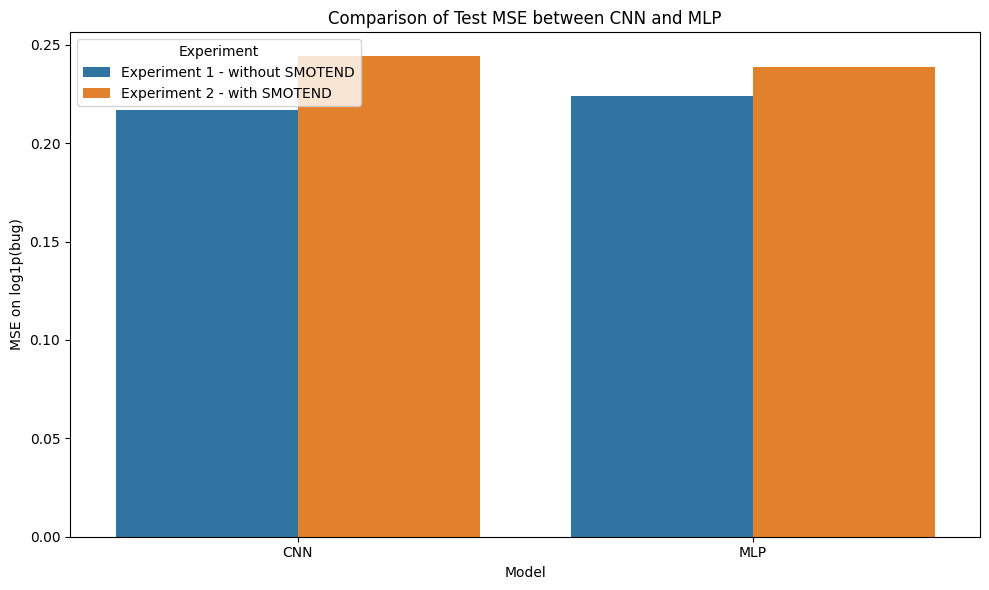

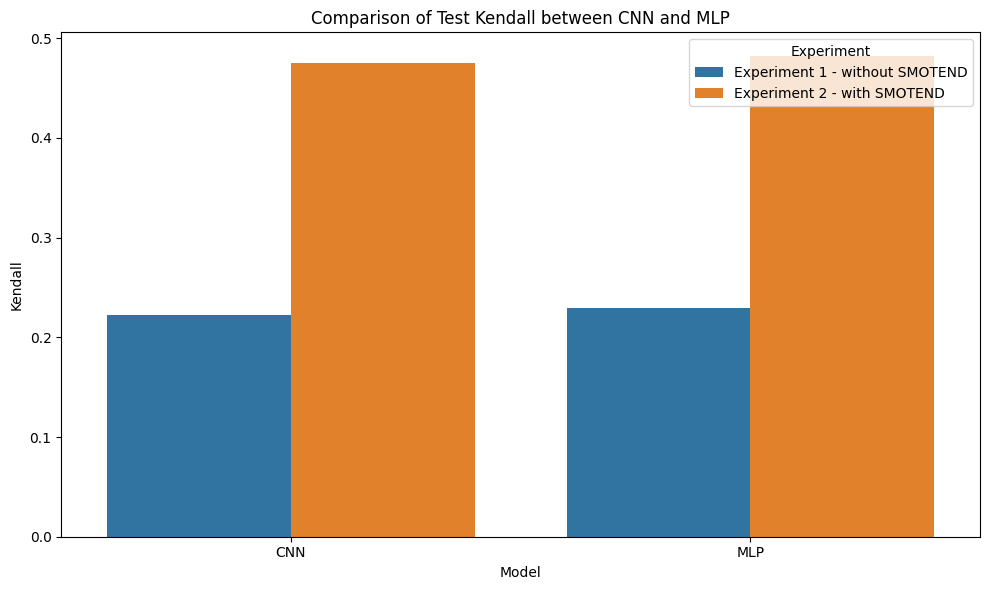

Pivot Test MSE:


Experiment,Experiment 1 - without SMOTEND,Experiment 2 - with SMOTEND
Model,,
CNN,0.2168,0.2441
MLP,0.2239,0.2386


Pivot Test Kendall:


Experiment,Experiment 1 - without SMOTEND,Experiment 2 - with SMOTEND
Model,,
CNN,0.2228,0.4751
MLP,0.2291,0.4818


In [19]:
# Chỉ dùng kết quả Deep Learning: CNN và MLP
final_results_df = deep_results_df.copy()

final_results_df = final_results_df.sort_values(
    ["Experiment", "Model", "Dataset"]
).reset_index(drop=True)

display(final_results_df)

final_results_df.to_csv(
    OUTPUT_DIR / "final_deep_learning_results.csv",
    index=False
)

# Chỉ lấy kết quả trên tập Test
test_results = final_results_df[
    final_results_df["Dataset"] == "Test"
].copy()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=test_results,
    x="Model",
    y="MSE",
    hue="Experiment"
)
plt.title("Comparison of Test MSE between CNN and MLP")
plt.xlabel("Model")
plt.ylabel("MSE on log1p(bug)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_compare_test_mse.png", dpi=200)
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(
    data=test_results,
    x="Model",
    y="Kendall",
    hue="Experiment"
)
plt.title("Comparison of Test Kendall between CNN and MLP")
plt.xlabel("Model")
plt.ylabel("Kendall")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "fig_compare_test_kendall.png", dpi=200)
plt.show()

pivot_test_mse = test_results.pivot_table(
    index="Model",
    columns="Experiment",
    values="MSE"
)

pivot_test_kendall = test_results.pivot_table(
    index="Model",
    columns="Experiment",
    values="Kendall"
)

print("Pivot Test MSE:")
display(pivot_test_mse)

print("Pivot Test Kendall:")
display(pivot_test_kendall)

pivot_test_mse.to_csv(OUTPUT_DIR / "table_pivot_test_mse.csv")
pivot_test_kendall.to_csv(OUTPUT_DIR / "table_pivot_test_kendall.csv")